Name : Salon Maharjan
ID : 2408391

**Introduction to Python Imaging Library(PIL)**

In [5]:
#Worksheet - 1
#Libraries used
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

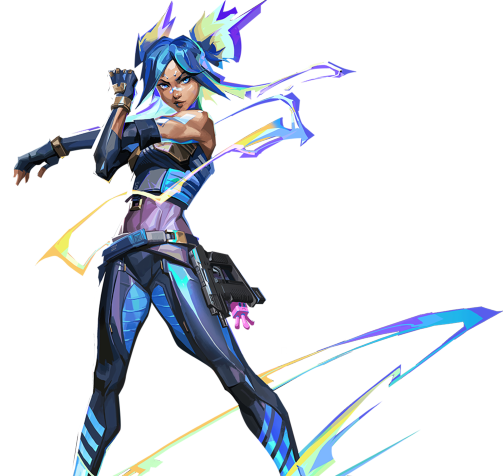

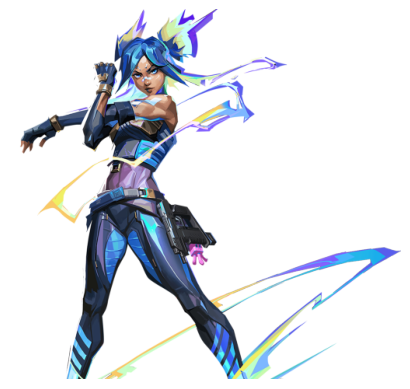

In [6]:
#Exercise - 1:
# 1. Read and display the image.

# Load and display the image file using Pillow
img = Image.open("/content/drive/MyDrive/Ai Photo/Neon.png")
display ( img )

# Display the image using matplotlib
plt.imshow(img)
plt.axis('off')  # Hides the x and y axis
plt.show()

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


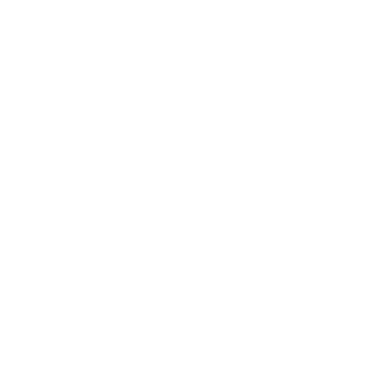

In [10]:
# 2. Display only the top left corner of 100x100 pixels.

# Convert the image object into a NumPy array so pixel values can be manipulated
img_array = np.array(img)

# Slice the NumPy array to obtain the 100x100 pixel region from the top-left corner
top_left = img_array[0:100, 0:100]

# Show the extracted part using matplotlib
plt.imshow(top_left)
plt.axis('off')
plt.show()

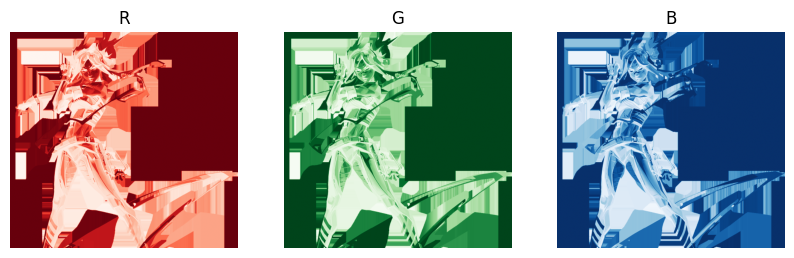

In [11]:
# 3. Show the three color channels (R, G, B).

# Split the RGB image into its individual Red, Green and Blue channels
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

# Display channels
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.title("R")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.title("G")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.title("B")
plt.axis("off")

plt.show()

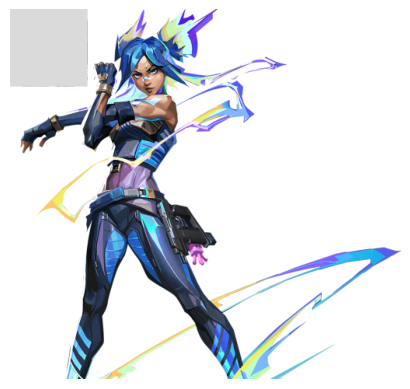

In [12]:
# 4. Modify the top 100 × 100 pixels to a value of 210 and display the resulting image:
img_array[0:100, 0:100] = 210

# Display the modified image
plt.imshow(img_array)
plt.axis('off')
plt.show()

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


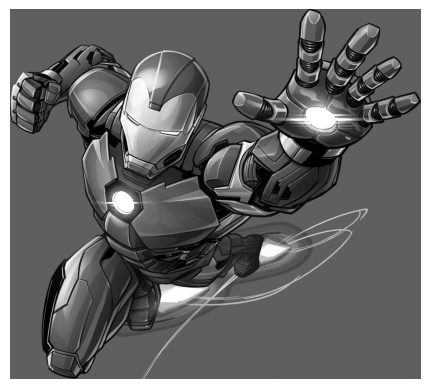

In [13]:
# Exercise 2
# 1. Load and display a grayscale image.
img = Image.open("/content/drive/MyDrive/Ai Photo/ironman.png").convert("L")

# Show the image and convert it to grayscale format
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

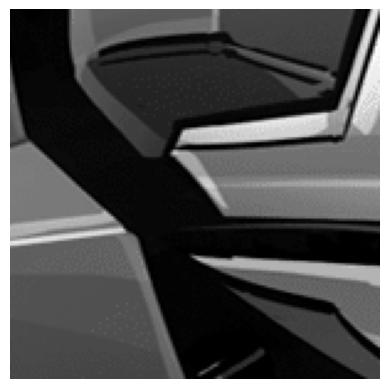

In [14]:
# 2. Extract and display the middle section of the image (150 pixels)
# Convert to NumPy array
img_array = np.array(img)

# Get image dimensions
h, w = img_array.shape

# Find center
center_h = h // 2
center_w = w // 2

# Extract 150x150 region from the center
cropped = img_array[center_h-75:center_h+75, center_w-75:center_w+75]

# Display cropped image
plt.imshow(cropped, cmap='gray')
plt.axis('off')
plt.show()

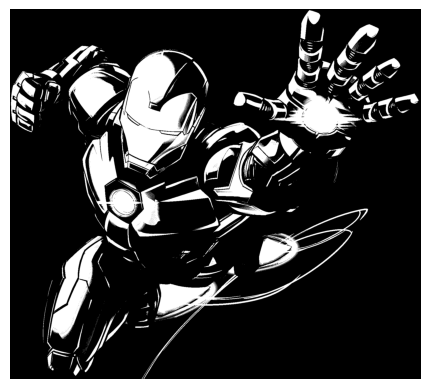

In [15]:
# 3. Apply a simple threshold to the image
# Apply threshold
binary_img = np.where(img_array < 100, 0, 255)

# Display binary image
plt.imshow(binary_img, cmap='gray')
plt.axis('off')
plt.show()

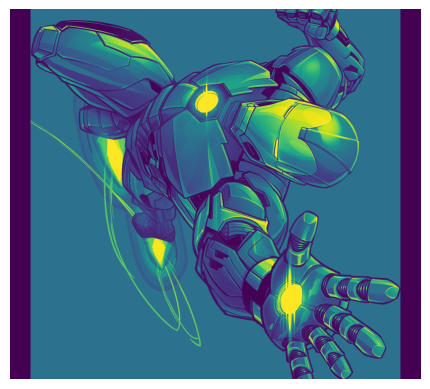

In [16]:
# 4. Rotate the image 90 degrees clockwise and display the result.
# Rotate 90 degrees clockwise
rotated_img = img.rotate(-90)

# Display the rotated image
plt.imshow(rotated_img)
plt.axis('off')
plt.show()

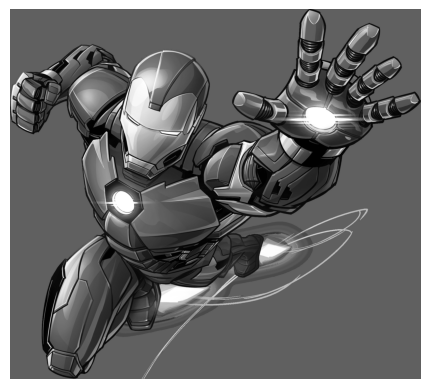

In [17]:
# 5. Convert the grayscale image to an RGB image.
# Convert to NumPy array
gray_array = np.array(img)

# Replicate grayscale values into 3 channels (RGB)
rgb_image = np.stack((gray_array, gray_array, gray_array), axis=-1)

# Display the RGB image
plt.imshow(rgb_image)
plt.axis('off')
plt.show()

**Image Compression and Decompression using PCA.**

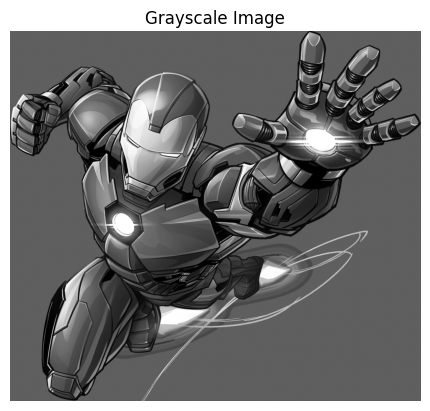

In [19]:
# Load image
img = Image.open("/content/drive/MyDrive/Ai Photo/ironman.png")

# Convert to grayscale if image is color
img = img.convert("L")

# Convert to NumPy array
img_array = np.array(img)

# Display grayscale image
plt.imshow(img_array, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

In [20]:
# Center the dataset (Standardize)

# Flatten the image into a 1D dataset
data = img_array.astype(float)

# Calculate mean and standard deviation
mean = np.mean(data, axis=0)
standardized_data = data - mean  # shape: (height, width)

print("Mean after standardization:", np.mean(standardized_data))
print("Std after standardization:", np.std(standardized_data))

Mean after standardization: 2.44528067966384e-16
Std after standardization: 43.579775991546065


In [21]:
# Covariance Matrix

# Calculate covariance matrix
cov_matrix = np.cov(standardized_data, rowvar=False)

print("Covariance Matrix:")
print(cov_matrix)

Covariance Matrix:
[[ 79.61739833  59.2948627   57.24724148 ...   9.4660856    7.27179558
    3.57182074]
 [ 59.2948627  106.15489519  88.54582542 ...  11.89382564   8.52926589
    4.49173015]
 [ 57.24724148  88.54582542 125.52340456 ...  11.14147393   8.1880905
    3.39847986]
 ...
 [  9.4660856   11.89382564  11.14147393 ...  44.70870565  33.26125866
   16.30178093]
 [  7.27179558   8.52926589   8.1880905  ...  33.26125866  29.640711
   16.1811818 ]
 [  3.57182074   4.49173015   3.39847986 ...  16.30178093  16.1811818
   15.14499691]]


In [30]:
# Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Convert eigenvalues and eigenvectors to real numbers
eigenvalues = np.real(eigenvalues)
eigenvectors = np.real(eigenvectors)

# Sort eigenvalues in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[sorted_indices]
eigenvectors_sorted = eigenvectors[:, sorted_indices]

print("Sorted Eigenvalues:", eigenvalues_sorted)
print("Corresponding Eigenvectors shape:", eigenvectors_sorted.shape)

Sorted Eigenvalues: [ 6.54569670e+05  3.83150430e+05  2.89332634e+05 ... -8.25781650e-12
 -9.08226997e-12 -1.00788725e-11]
Corresponding Eigenvectors shape: (1800, 1800)


/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


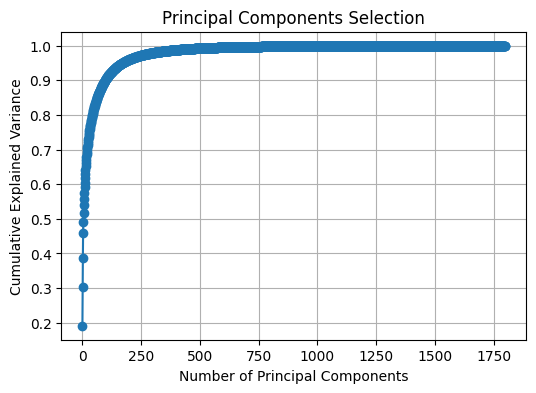

In [23]:
# Cumulative variance plot
cumulative_variance = np.cumsum(eigenvalues_sorted) / np.sum(eigenvalues_sorted)

plt.figure(figsize=(6,4))
plt.plot(cumulative_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Principal Components Selection')
plt.grid(True)
plt.show()

In [24]:
# Choose top k eigenvectors that explain > 95% variance
k = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of principal components to retain 95% variance: {k}")
top_k_eigenvectors = eigenvectors_sorted[:, :k]

Number of principal components to retain 95% variance: 171


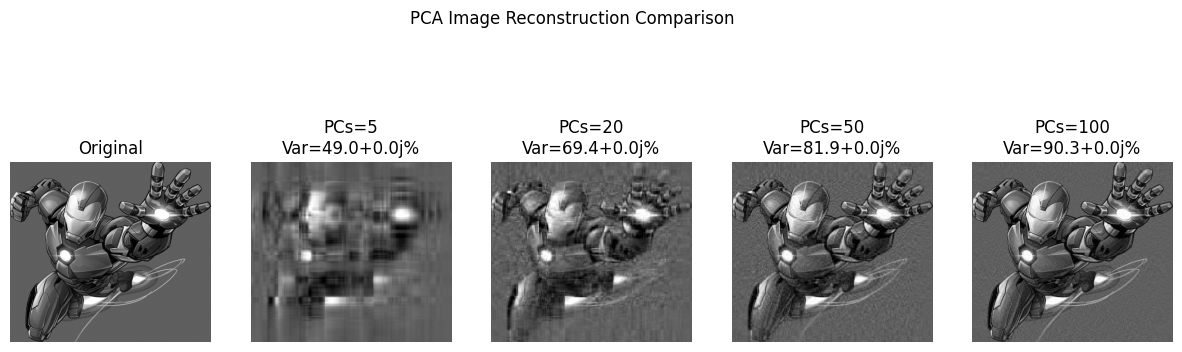

In [31]:
# Function to reconstruct using top k components
def reconstruct_image(data_std, mean, eigenvectors, k):
    top_k_eigvecs = eigenvectors[:, :k]         # select top k eigenvectors
    lower_dim = np.dot(data_std, top_k_eigvecs) # project to lower dimension
    reconstruction = np.dot(lower_dim, top_k_eigvecs.T) + mean
    return reconstruction

# Experiments: Pick 4 different k values
k_values = [5, 20, 50, 100]  # Number of principal components
plt.figure(figsize=(15, 5))

# Display original image
plt.subplot(1, len(k_values)+1, 1)
plt.imshow(img_array, cmap='gray')
plt.title("Original")
plt.axis('off')

# Display reconstructed images
for i, k in enumerate(k_values):
    reconstructed = reconstruct_image(standardized_data, mean, eigenvectors_sorted, k)
    # Clip and convert to uint8 for proper display
    reconstructed = np.clip(reconstructed, 0, 255).astype(np.uint8)

    plt.subplot(1, len(k_values)+1, i+2)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f"PCs={k}\nVar={cumulative_variance[k-1]*100:.1f}%")
    plt.axis('off')

plt.suptitle("PCA Image Reconstruction Comparison")
plt.show()